In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [3]:
df=pd.read_csv('height-weight.csv')

In [4]:
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


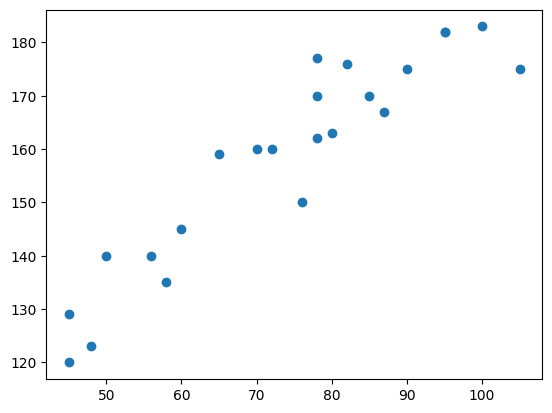

In [5]:
plt.scatter(df['Weight'],df['Height'])

In [8]:
X=df[['Weight']]### Independent Feature 2d or dataframe
y=df['Height']

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
X_train

,Weight
12,105
1,58
13,100
5,78
2,48
11,95
20,45
3,60
4,70
18,76


In [ ]:
# scaling 
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler() # to get gradient descent quickly 

In [14]:
X_train_scaled=Scaler.fit_transform(X_train)
X_test_scaled=Scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
model=LinearRegression()

In [20]:
model.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
model.coef_ #slope 

array([17.03440872])

In [32]:
model.intercept_

np.float64(157.5)

In [21]:
y_pred=model.predict(X_test_scaled)

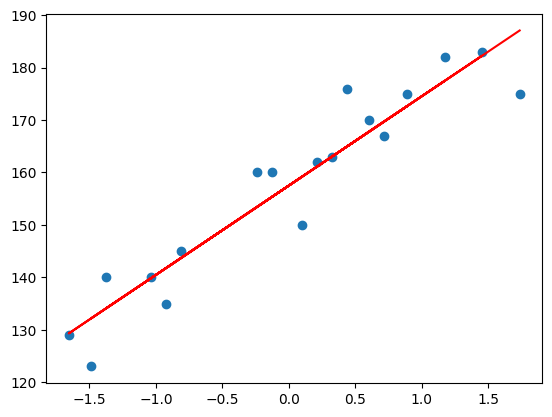

In [35]:
plt.scatter(X_train_scaled,y_train)
plt.plot(X_train_scaled,model.predict(X_train_scaled),color='r')

In [28]:
y_test

15    177
9     170
0     120
8     182
17    159
Name: Height, dtype: int64

In [29]:
y_pred

array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
       148.56507414])

In [36]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=root_mean_squared_error(y_test,y_pred) # or np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("mse = ",mse)
print("mae = ",mae)
print("rmse = ",rmse)
print("r2 = ",r2)

mse =  109.77592599051664
mae =  9.822657814519232
rmse =  10.477400726827081
r2 =  0.776986986042344


In [37]:
n=X_train.shape[0]

In [38]:
p=X_train.shape[1]

In [40]:
#adjusted r2 
Adjr2= 1-(((1-r2)*(n-1))/(n-p-1))

In [42]:
Adjr2

0.7630486726699904

In [44]:
# predict for weight is 80 
model.predict(Scaler.transform([[80]]))

C:\Users\ayush\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([163.01076266])

In [45]:
### assumptions when do  you say model is perfect or very good 

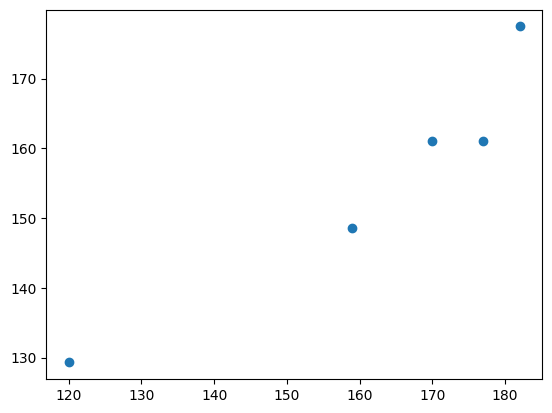

In [48]:
# plot scatter for prediction 
plt.scatter(y_test,y_pred) # if data is linearly scattered then good model

In [50]:
### calculate residuals 
residual=y_test-y_pred

In [51]:
residual

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

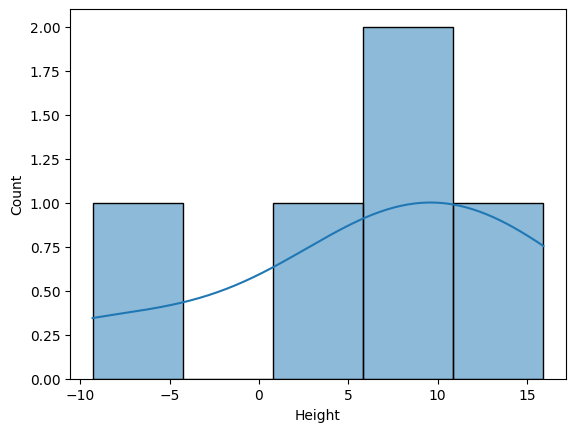

In [56]:
sns.histplot(residual,bins=5,kde=True)